# Stride reference solutions: fine-grid forward + coarse-grid FWI

This notebook produces three Stride reference solutions:

1. Fine-grid acoustic forward modelling for low-dispersion synthetic observations.
2. Coarse-grid Stride FWI from homogeneous water.
3. Coarse-grid Stride FWI from an exact-skull / water-interior start.

The forward and inverse problems use separate Stride grids and separate
IsoAcousticDevito operators. NumPy is used only for model construction,
trace-time interpolation, diagnostics, and saving files

running this notebook in the stride conda environment

## Configuration

DEV_MODE = False. The fine and inversion domains
have the same physical size, geometry, source pulse and shot ordering, but
different spatial and temporal discretisations.

In [1]:
import os

os.environ["DISPLAY"] = ":0"
os.environ["DEVITO_LANGUAGE"] = "C"

%matplotlib inline

In [2]:
DEV_MODE = True

DOMAIN_M = 0.25
FINE_INTERIOR = (50, 50) if DEV_MODE else (250, 250)
INV_INTERIOR = (50, 50) if DEV_MODE else (125, 125)

F_CENTRE = 200e3 # centre frequency of 200kHz
N_CYCLES = 3
N_RECEIVERS = 16 if DEV_MODE else 16 # should put even more as in breast 2d example
RESOLUTION_TAG = FINE_INTERIOR[0] # if (250,250) then res 250

# "Perfect skull start" means exact skull values and water elsewhere.
# The skull is allowed to update during FWI.
FREEZE_SKULL = False # start with a perfect skull, but allow FWI to modify it.
if FREEZE_SKULL:
    raise NotImplementedError(
        "This notebook implements a perfect-skull initialisation, not a fixed-skull constraint."
    )

In [3]:
import sys
import importlib
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import stride_reference_fixed as ref
importlib.reload(ref)
print("Devito config:", ref.configure_devito())
print("Helper version:", ref.REF_VERSION)

import mosaic
try:
    await mosaic.interactive("off")
except Exception as exc:
    print("Stop warning:", exc)

mosaic.clear_runtime()
print("Mosaic cleared")
import numpy as np
import matplotlib.pyplot as plt

from stride import (
    GradientDescent,  # FWI optimiser
    IsoAcousticDevito,  # wave-eq solver
    L2DistanceLoss,  # distance between modelled and observed data
    OptimisationLoop,
    ProcessGlobalGradient,
    ProcessModelIteration,
    ScalarField,
    adjoint,
    forward,
)

OUT = ref.reference_dir(RESOLUTION_TAG)
OUT

Devito config: serial C (macOS — avoids omp.h / libomp clash)
Helper version: 5
Mosaic cleared


PosixPath('/Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/50')

## 1. Build two complete Stride problems

problem_ref is used only to generate observations. problem_inv is the
coarser problem on which both FWI experiments are run.

Fine grid: <stride.problem.domain.Grid object at 0x306082d10>
Inverse grid: <stride.problem.domain.Grid object at 0x3079d3750>
Fine dt=5.466e-07s, PPW at centre≈1.5
Inv  dt=5.466e-07s, PPW at centre≈1.5


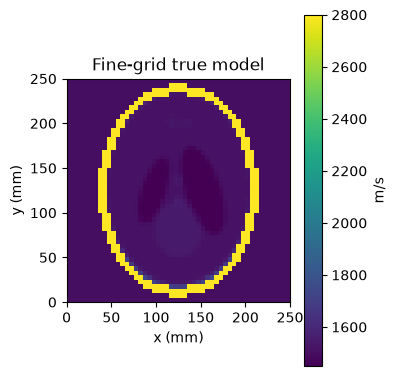

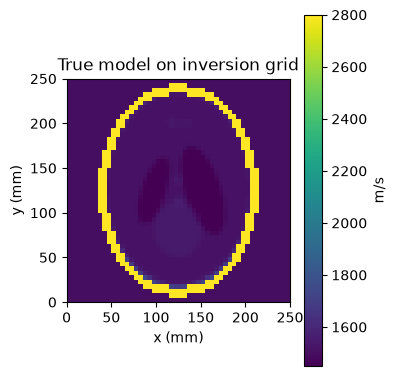

<Axes: title={'center': 'True model on inversion grid'}, xlabel='x (mm)', ylabel='y (mm)'>

In [4]:
problem_ref, vp_true_ref, vp_true_ref_array, meta_ref = ref.build_stride_problem(
    name=f"shepp_logan_reference_{RESOLUTION_TAG}",
    interior_shape=FINE_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,
)

problem_inv, vp_true_inv_field, vp_true_inv_array, meta_inv = ref.build_stride_problem(
    name=f"shepp_logan_inversion_{INV_INTERIOR[0]}",
    interior_shape=INV_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,
)

ref.save_vp_npy(vp_true_ref, OUT / "vp_true_fine.npy")
ref.save_vp_npy_from_array(vp_true_inv_array, OUT / "vp_true_inversion_grid.npy")
ref.save_vp_npy_from_array(
    ref.water_model(INV_INTERIOR),
    OUT / "vp_water_inversion_grid.npy",
)
ref.save_grid_meta(
    problem_ref,
    OUT / "grid_meta_fine.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)
ref.save_grid_meta(
    problem_inv,
    OUT / "grid_meta_inversion.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)

ppw_ref = ref.SOS_WATER / (F_CENTRE * meta_ref["spacing"][0])
ppw_inv = ref.SOS_WATER / (F_CENTRE * meta_inv["spacing"][0])

print("Fine grid:", problem_ref.grid)
print("Inverse grid:", problem_inv.grid)
print(f"Fine dt={meta_ref['dt']:.3e}s, PPW at centre≈{ppw_ref:.1f}")
print(f"Inv  dt={meta_inv['dt']:.3e}s, PPW at centre≈{ppw_inv:.1f}")

ref.plot_vp(vp_true_ref, domain_m=DOMAIN_M, title="Fine-grid true model")
ref.plot_vp(vp_true_inv_field, domain_m=DOMAIN_M, title="True model on inversion grid")

## 2. Fine-grid Stride forward reference

This uses IsoAcousticDevito on problem_ref.grid. The generated observations
are saved and then resampled onto the inversion problem's time axis.

In [ ]:
runtime = await ref.ensure_mosaic_runtime(num_workers=1, log_level="info")
print("Mosaic ready, workers:", runtime.num_workers)

pde_ref = IsoAcousticDevito.remote(  # creates aucustic wave eq solver
    grid=problem_ref.grid,
    len=runtime.num_workers,
)
# acc forward modelling

await forward(
    problem_ref,
    pde_ref,
    vp_true_ref,
    dump=True,
)

ref.check_forward_ready(problem_ref)
ref.export_shot_observed_npy(problem_ref, OUT / "forward_fine")
print("Fine-grid observations saved to", OUT / "forward_fine")

Listening at <CommsManager object at 13007611536, uid=monitor, address=192.168.1.181, port=3015, state=connected>HEAD            Listening at <CommsManager object at 13002005008, uid=head, address=192.168.1.181, port=3018, state=connected>
Mosaic ready, workers: 1
HEAD            No need to run forward, observed already exists
Forward OK: 16/16 shots with observed
Fine-grid observations saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/50/forward_fine


MONITOR         Listening at <NODE:0 | WORKER:0-1>
WORKER:0:0      (ShotID 0) Spatial grid spacing (5.102 mm | 1.509 PPW) is higher than dispersion limit (1.540 mm | 5.000 PPW)
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      (ShotID 1) Spatial grid spacing (5.102 mm | 1.509 PPW) is higher than dispersion limit (1.540 mm | 5.000 PPW)
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      (ShotID 2) Spatial grid spacing (5.102 mm | 1.509 PPW) is higher than dispersion limit (1.540 mm | 5.000 PPW)
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      (ShotID 3) Spatial grid spacing (5.102 mm | 1.509 PPW) is higher than dispersion limit (1.540 mm | 5.000 PPW)
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:0   

## 3. Transfer observations to the coarse Stride problem

The physical source/receiver geometry is unchanged. each receiver trace is
interpolated from the fine time sampling to problem_inv.time
soo:
- the same source and receiver geometry,
- the same shot ordering,
- the same physical experiment,
- but different time steps because their spatial grids are different

In [6]:
ref.transfer_observed_to_problem(
    problem_ref,
    problem_inv,
    check_geometry=True,
)

ref.export_shot_observed_npy(problem_inv, OUT / "observed_on_inversion_grid")
print(ref.observed_trace_difference(problem_ref, problem_inv, shot_id=0))

Forward OK: 16/16 shots with observed
{'source_shape': (16, 864), 'target_shape': (16, 864), 'source_max_abs': 0.3810385465621948, 'target_max_abs': 0.3810385465621948}


### shot gather

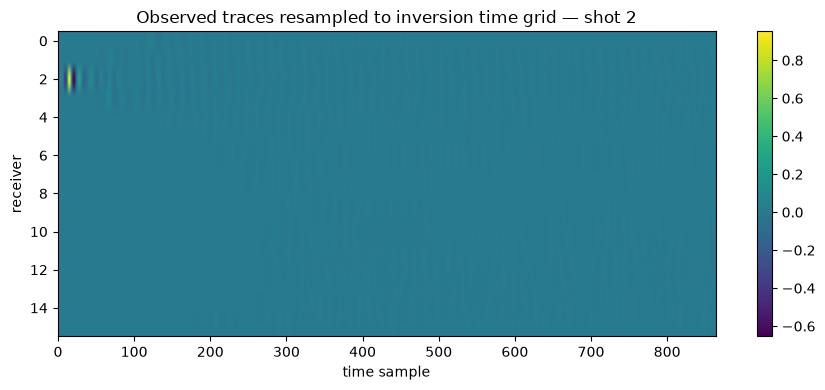

In [7]:
shot_id = 2
fine_trace = np.asarray(problem_ref.acquisitions.get(shot_id).observed.data)
inv_trace = np.asarray(problem_inv.acquisitions.get(shot_id).observed.data)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(inv_trace, aspect="auto", origin="upper")
ax.set_title(f"Observed traces resampled to inversion time grid — shot {shot_id}")
ax.set_xlabel("time sample")
ax.set_ylabel("receiver")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Configure the coarse-grid Stride FWI operator

Both starts use the same observations, inverse grid, loss, frequency schedule,
shot selection and physical bounds.

In [8]:
pde_inv = IsoAcousticDevito.remote(
    grid=problem_inv.grid,
    len=runtime.num_workers,
)

max_freqs = [0.1e6] if DEV_MODE else [0.1e6, 0.15e6, 0.2e6] # starts with lower freq and gradually increase
num_iters = 15
shots_per_iteration = len(problem_inv.acquisitions.shots)

def make_fwi_components(vp):
    loss = L2DistanceLoss.remote(len=runtime.num_workers)
    optimiser = GradientDescent(
        vp,
        step_size=1,
        process_grad=ProcessGlobalGradient(),
        process_model=ProcessModelIteration(min=1400.0, max=3000.0),
    )
    return loss, optimiser, OptimisationLoop()

async def run_fwi(vp):
    ref.set_medium_vp(problem_inv, vp)
    ref.check_forward_ready(problem_inv)

    loss, optimiser, optimisation_loop = make_fwi_components(vp)

    for _, frequency in optimisation_loop.blocks(len(max_freqs), max_freqs):
        await adjoint(
            problem_inv,
            pde_inv,
            loss,
            optimisation_loop,
            optimiser,
            vp,
            num_iters=num_iters,
            select_shots=dict(
                num=shots_per_iteration,
                randomly=False,
            ),
            f_max=frequency,
            max_freqs=max_freqs,
        )

    return vp

## 5. FWI from homogeneous water

The inversion parameter belongs to problem_inv.grid, not the fine reference
grid.

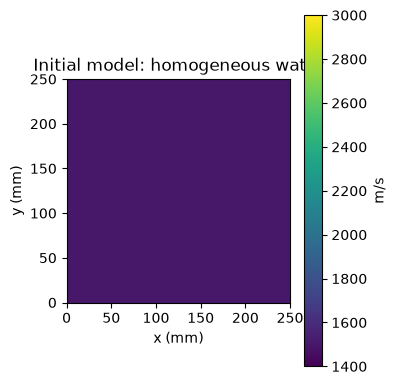

Forward OK: 16/16 shots with observed


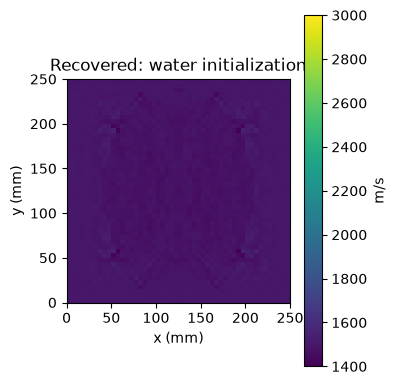

Water-start FWI saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/50/fwi/water_start


In [9]:
water_start_array = ref.water_model(INV_INTERIOR)

vp_water_start = ref.inversion_vp_from_array(
    problem_inv,
    water_start_array,
)

ref.save_vp_npy_from_array(
    water_start_array,
    OUT / "fwi" / "water_start" / "vp_initial.npy",
)

# Plot the initial homogeneous-water model
ref.plot_vp(
    water_start_array,
    domain_m=DOMAIN_M,
    title="Initial model: homogeneous water",
    vmin=1400,
    vmax=3000
)

# Run FWI
vp_water_recovered = await run_fwi(vp_water_start)

water_dir = OUT / "fwi" / "water_start"

ref.save_vp_npy(
    vp_water_recovered,
    water_dir / "vp_recovered.npy",
)

# Plot the recovered model
ref.plot_vp(
    vp_water_recovered,
    domain_m=DOMAIN_M,
    title="Recovered: water initialization",
    vmin=1400,
    vmax=3000
)

print("Water-start FWI saved to", water_dir)

## 6. FWI from an exact-skull / water-interior start

This is not the complete true model. Only pixels classified as skull retain
their true inversion grid velocity, every non-skull pixel is reset to water

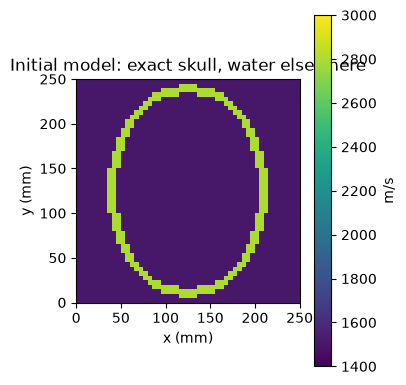

Forward OK: 16/16 shots with observed


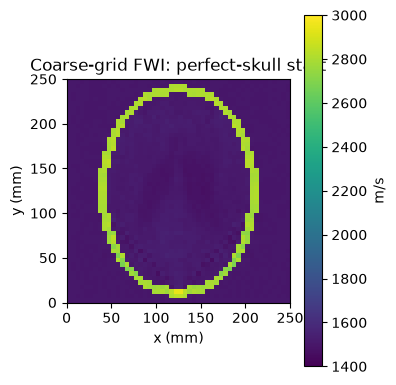

Perfect-skull-start FWI saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/50/fwi/perfect_skull_start


In [10]:
perfect_skull_array, skull_mask = ref.perfect_skull_start(
    vp_true_inv_array,
    c_water=ref.SOS_WATER,
)

vp_perfect_skull_start = ref.inversion_vp_from_array(
    problem_inv,
    perfect_skull_array,
)

# Show INITIAL model
ref.plot_vp(
    perfect_skull_array,
    domain_m=DOMAIN_M,
    title="Initial model: exact skull, water elsewhere",
    vmin=1400,
    vmax=3000
)

# Run FWI
vp_perfect_skull_recovered = await run_fwi(vp_perfect_skull_start)

perfect_dir = OUT / "fwi" / "perfect_skull_start"

ref.save_vp_npy(
    vp_perfect_skull_recovered,
    perfect_dir / "vp_recovered.npy",
)
ref.plot_vp(
    vp_perfect_skull_recovered,
    domain_m=DOMAIN_M,
    title="Coarse-grid FWI: perfect-skull start",
    vmin=1400,
    vmax=3000

)
print("Perfect-skull-start FWI saved to", perfect_dir)

## 7. Compare and export

The FWI outputs are already on the intended inversion grid. No post-hoc
downsampling is used to pretend that a fine-grid inversion was coarse.

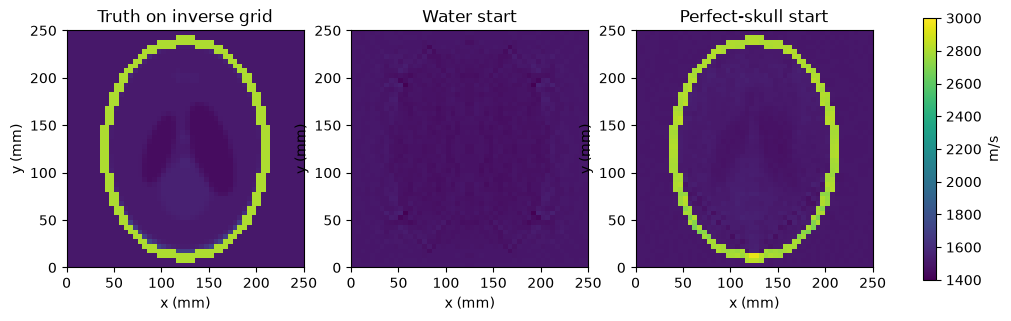

Comparison files saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/50/comparison


In [11]:
comparison_dir = OUT / "comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

np.save(comparison_dir / "vp_true.npy", vp_true_inv_array)
np.save(comparison_dir / "vp_water_initial.npy", water_start_array)
np.save(comparison_dir / "vp_perfect_skull_initial.npy", perfect_skull_array)
np.save(
    comparison_dir / "vp_water_recovered.npy",
    np.asarray(vp_water_recovered.data, dtype=np.float32),
)
np.save(
    comparison_dir / "vp_perfect_skull_recovered.npy",
    np.asarray(vp_perfect_skull_recovered.data, dtype=np.float32),
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in [
    (axes[0], vp_true_inv_array, "Truth on inverse grid"),
    (axes[1], np.asarray(vp_water_recovered.data), "Water start"),
    (axes[2], np.asarray(vp_perfect_skull_recovered.data), "Perfect-skull start"),
]:
    im = ax.imshow(
        data.T,
        origin="lower",
        extent=ref.domain_extent_mm(DOMAIN_M),
        vmin=1400,
        vmax=3000,
    )
    ax.set_title(title)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

fig.colorbar(im, ax=axes.ravel().tolist(), label="m/s", shrink=0.85)
plt.show()

print("Comparison files saved to", comparison_dir)
await mosaic.interactive("off")